# CORRELATION FUNCTION AND BISPECTRUM EXAMPLE

In [18]:
import numpy as np
import numpy.fft as fft
import pylab as plt
import pyccl as ccl
#plt.rcParams["figure.figsize"] = (14,7)
import fastbox
from fastbox.box import CosmoBox, default_cosmo
from fastbox.foregrounds import ForegroundModel
import fastbox.power as power

#from power import *
import time, sys


## GENERATE DENSITY FIELD

In [19]:
box = CosmoBox(cosmo=default_cosmo, box_scale=(1e3,1e3,1e3), nsamp=64, 
               redshift=0.8, realise_now=False)
_ = box.realise_density()

 /home/bruno/anaconda3/envs/fast-test/lib/python3.8/site-packages/pyccl/pk2d.py:207: RuntimeWarning:divide by zero encountered in log


## HI TRACER

In [20]:
tracer = fastbox.tracers.HITracer(box)
delta_hi = box.delta_x * tracer.bias_HI()

delta_hi_ln = box.lognormal(delta_hi)
hi_cube = tracer.signal_amplitude() * (1. + delta_hi_ln)

In [21]:
# INITIALIZE POWER OBJECT
power_obj = power.Power(box)

In [22]:
# CALCULATE 2PCF
r_vals, xi_vals = power_obj.est_2pcf(hi_cube)

## NBODYKIT ESTIMATION FOR COMPARISON

In [6]:

from nbodykit.lab import ArrayMesh
from nbodykit.algorithms.fftcorr import FFTCorr
from nbodykit.algorithms.fftpower import FFTPower

boxsize = (box.Lx, box.Ly, box.Lz)
mesh_true = ArrayMesh(hi_cube, BoxSize=boxsize)

corrfn_true = FFTCorr(first=mesh_true, mode='1d', BoxSize=boxsize, 
                      los=[0, 0, 1], dr=r_vals[2]-r_vals[1], rmin=r_vals[0], rmax=r_vals[-1])
#corr_true, _ = corrfn_true.run()
corr_true, _ = corrfn_true.run()

r = corr_true['r']
xi_nbkit =  corr_true['corr']

In [7]:
# THEORY CALCULATION WITH CCL

xi = ccl.correlation_multipole(box.cosmo, a=box.scale_factor, l=0, s=r_vals, beta=0.)
ampsq = (tracer.signal_amplitude() * tracer.bias_HI())**2.

## PLOTTING

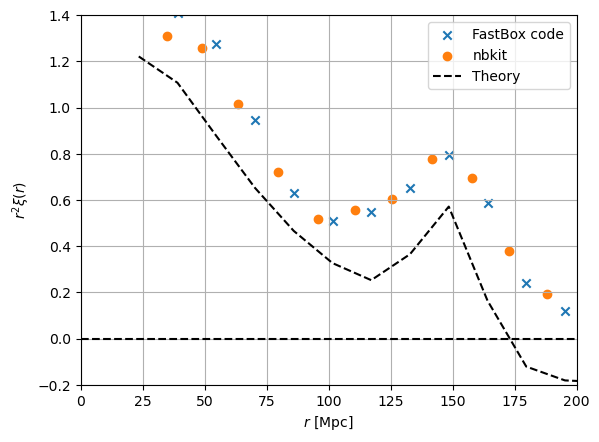

In [8]:
# PLOTTING
plt.scatter(r_vals, xi_vals * r_vals**2,marker='x',label='FastBox code')
plt.scatter(r, r**2. *xi_nbkit, label="nbkit",marker='o')
plt.plot(r_vals, ampsq*xi * r_vals**2,linestyle='--',label='Theory',color='k')
plt.axhline(0, color='k', linestyle='--')
plt.xlabel(r'$r \ [\mathrm{Mpc}]$')
plt.ylabel(r'$r^2 \xi(r)$')
plt.xlim(0,200)
plt.grid()
plt.legend()
plt.ylim(-0.2,1.4)
plt.show()

# BISPECTRUM

In [17]:
# CREATE A GAUSSIAN FIELD AS A REFERENCE FOR THE LOGNORMAL CASE
tracer = fastbox.tracers.HITracer(box)
delta_hi = box.delta_x * tracer.bias_HI()

hi_cube_gauss = tracer.signal_amplitude() * (1. + delta_hi)

In [13]:
k_vals, B_vals, tri_counts = power_obj.bispectrum_equilateral(hi_cube, MAS=None, n_bins=8)
k_vals_gauss, B_vals_gauss, tri_counts_gauss = power_obj.bispectrum_equilateral(hi_cube_gauss, MAS=None, n_bins=8)

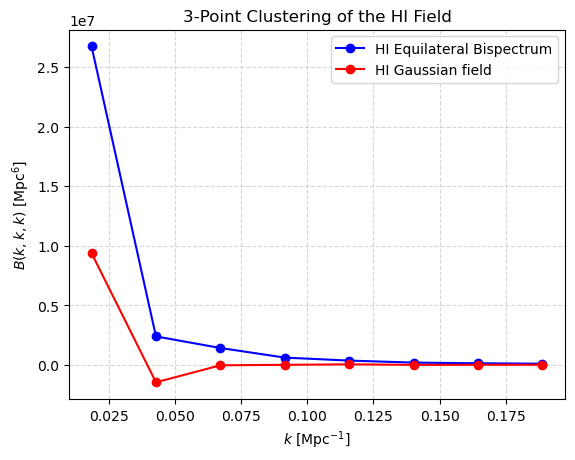

In [16]:
plt.plot(k_vals, B_vals, marker='o', linestyle='-', color='b', label='HI Equilateral Bispectrum')
plt.plot(k_vals_gauss, B_vals_gauss, marker='o', linestyle='-', color='r', label='HI Gaussian field')

plt.xlabel(r'$k \ [\mathrm{Mpc}^{-1}]$')
plt.ylabel(r'$B(k, k, k) \ [\mathrm{Mpc}^6]$')
plt.title('3-Point Clustering of the HI Field')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.show()